In [2]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
sns.set()
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [3]:
data = pd.read_csv('/content/Churn_Modelling.csv')
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### Drop irrelevent features

In [5]:
data=data.drop(['RowNumber','CustomerId','Surname'],axis=1)

In [6]:
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


### check Missing Data

In [8]:
data.isnull().sum()

,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0


In [9]:
data.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [10]:
y=data['Exited']
data=data.drop("Exited",axis=1)

In [11]:
y.head()

,Exited
0,1
1,0
2,1
3,0
4,0


In [12]:
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


### Encoding

In [13]:
data['Gender']=data['Gender'].astype('category')
data['Gender']=data['Gender'].cat.codes

In [14]:
data['Geography'] = data['Geography'].astype('category')
data['Geography'] = data['Geography'].cat.codes

In [15]:
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,0,0,42,2,0.00,1,1,1,101348.88
1,608,2,0,41,1,83807.86,1,0,1,112542.58
2,502,0,0,42,8,159660.80,3,1,0,113931.57
3,699,0,0,39,1,0.00,2,0,0,93826.63
4,850,2,0,43,2,125510.82,1,1,1,79084.10


In [16]:
y.value_counts()
#data is imbalanced

,count
Exited,
0,7963
1,2037


In [17]:
x=data.copy()

In [18]:
x.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,0,0,42,2,0.00,1,1,1,101348.88
1,608,2,0,41,1,83807.86,1,0,1,112542.58
2,502,0,0,42,8,159660.80,3,1,0,113931.57
3,699,0,0,39,1,0.00,2,0,0,93826.63
4,850,2,0,43,2,125510.82,1,1,1,79084.10


### Imbalance treatment

In [19]:
import imblearn
from imblearn.over_sampling import SMOTE
sm=SMOTE(random_state=42)
x_over,y_over=sm.fit_resample(x,y)
print(y.value_counts())
print(y_over.value_counts())

Exited
0    7963
1    2037
Name: count, dtype: int64
Exited
1    7963
0    7963
Name: count, dtype: int64


### train-test split¶

In [20]:
#split the data into train and test
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_over,y_over,test_size=0.2,random_state=45,stratify=y_over)

In [21]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(12740, 10)
(3186, 10)
(12740,)
(3186,)


### Scaling

In [22]:
#scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

# Scale training data
x_train= scaler.fit_transform(x_train)

# Scale test data
x_test= scaler.transform(x_test)

### Check for multicollinearity

<Axes: >

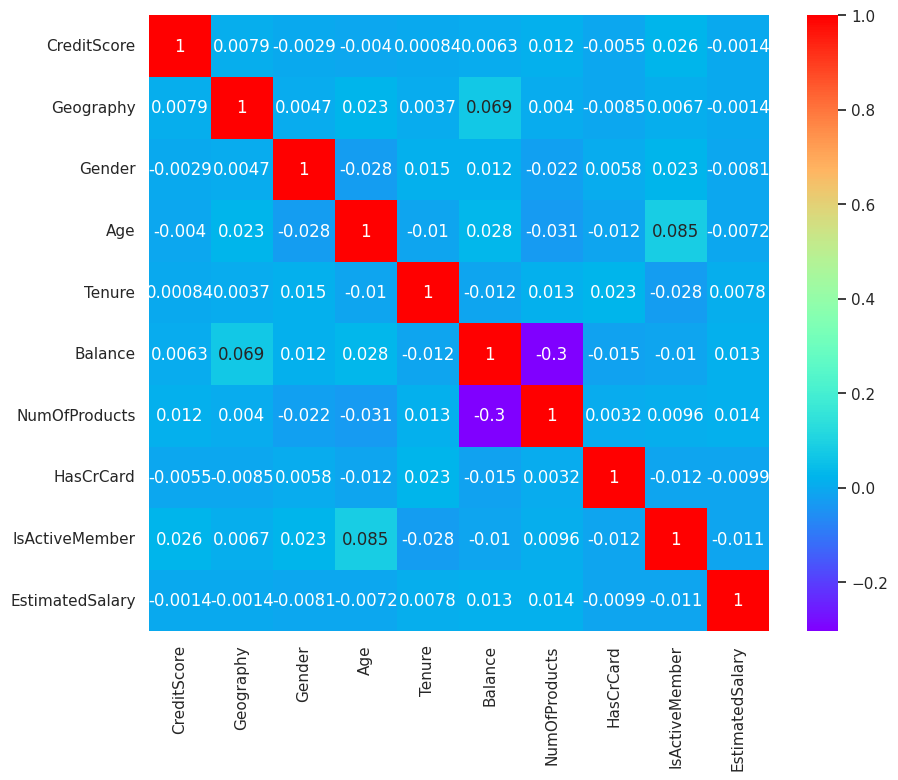

In [23]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(),annot=True,cmap='rainbow')

# Model Building

## Adaboost

In [25]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(algorithm="SAMME",random_state=42)

ada_params = {
    'n_estimators':[50,100,200],
    'learning_rate':[0.01,0.1,1]
}

ada_grid = GridSearchCV(
    ada,
    ada_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

ada_grid.fit(x_train,y_train)

print("Best AdaBoost Parameters:",ada_grid.best_params_)
print("Best AdaBoost ROC-AUC:",ada_grid.best_score_)

Best AdaBoost Parameters: {'learning_rate': 1, 'n_estimators': 200}
Best AdaBoost ROC-AUC: 0.9043609171720857


In [26]:
# Best tuned model
best_ada = ada_grid.best_estimator_
# Predictions
y_pred_test_ada = best_ada.predict(x_test)

In [27]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score

In [28]:
print("confusion matrix test adaboost",confusion_matrix(y_test,y_pred_test_ada))
print("**********************************************************************")
print("classification_report test adaboost",classification_report(y_test,y_pred_test_ada))
print("**********************************************************************")
print("accuracy_score test adaboost",accuracy_score(y_test,y_pred_test_ada))


confusion matrix test adaboost [[1285  308]
 [ 267 1326]]
**********************************************************************
classification_report test adaboost               precision    recall  f1-score   support

           0       0.83      0.81      0.82      1593
           1       0.81      0.83      0.82      1593

    accuracy                           0.82      3186
   macro avg       0.82      0.82      0.82      3186
weighted avg       0.82      0.82      0.82      3186

**********************************************************************
accuracy_score test adaboost 0.8195229127432517


In [29]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb_params = {
    'n_estimators':[100,200,300],
    'learning_rate':[0.01,0.05,0.1],
    'max_depth':[3,5,7],
    'subsample':[0.8,1],
    'colsample_bytree':[0.8,1]
}

xgb_grid = GridSearchCV(
    xgb,
    xgb_params,
    cv=5,
    scoring={
        'roc_auc':'roc_auc',
        'accuracy':'accuracy',
        'f1':'f1'
    },
    refit='roc_auc',
    n_jobs=-1
)

xgb_grid.fit(x_train,y_train)

print("Best XGB Parameters:",xgb_grid.best_params_)
print("Best XGB ROC-AUC:",xgb_grid.best_score_)

Best XGB Parameters: {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}
Best XGB ROC-AUC: 0.9364363714330073


In [33]:
# Best tuned model
best_xgb = xgb_grid.best_estimator_
# Predictions
y_pred_test_xgb = best_xgb.predict(x_test)


In [34]:
print("confusion matrix test XGB",confusion_matrix(y_test,y_pred_test_xgb))
print("**********************************************************************")
print("classification_report test XGB",classification_report(y_test,y_pred_test_xgb))
print("**********************************************************************")
print("accuracy_score test XGB",accuracy_score(y_test,y_pred_test_xgb))


confusion matrix test XGB [[1365  228]
 [ 187 1406]]
**********************************************************************
classification_report test XGB               precision    recall  f1-score   support

           0       0.88      0.86      0.87      1593
           1       0.86      0.88      0.87      1593

    accuracy                           0.87      3186
   macro avg       0.87      0.87      0.87      3186
weighted avg       0.87      0.87      0.87      3186

**********************************************************************
accuracy_score test XGB 0.8697426239799121


## LightGBM

In [32]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(random_state=42,verbose=-1)

lgbm_params = {
    'n_estimators':[100,200,300],
    'learning_rate':[0.01,0.05,0.1],
    'num_leaves':[31,50,70],
    'max_depth':[-1,5,10],
    'subsample':[0.8,1]
}

lgbm_grid = GridSearchCV(
    lgbm,
    lgbm_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

lgbm_grid.fit(x_train,y_train)

print("Best LightGBM Parameters:",lgbm_grid.best_params_)
print("Best LightGBM ROC-AUC:",lgbm_grid.best_score_)

Best LightGBM Parameters: {'learning_rate': 0.1, 'max_depth': -1, 'n_estimators': 300, 'num_leaves': 70, 'subsample': 0.8}
Best LightGBM ROC-AUC: 0.9380938415699573


In [35]:
# Best tuned model
best_lgbm = lgbm_grid.best_estimator_
# Predictions
y_pred_test_lgbm = best_lgbm.predict(x_test)


In [36]:
print("confusion matrix test LightGBM",confusion_matrix(y_test,y_pred_test_lgbm))
print("**********************************************************************")
print("classification_report test LightGBM",classification_report(y_test,y_pred_test_lgbm))
print("**********************************************************************")
print("accuracy_score test LightGBM",accuracy_score(y_test,y_pred_test_lgbm))


confusion matrix test LightGBM [[1364  229]
 [ 173 1420]]
**********************************************************************
classification_report test LightGBM               precision    recall  f1-score   support

           0       0.89      0.86      0.87      1593
           1       0.86      0.89      0.88      1593

    accuracy                           0.87      3186
   macro avg       0.87      0.87      0.87      3186
weighted avg       0.87      0.87      0.87      3186

**********************************************************************
accuracy_score test LightGBM 0.8738229755178908


## Random Forest Classifier

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)

rf_params = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,15],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4],
    'max_features':['sqrt','log2']
}

rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

rf_grid.fit(x_train,y_train)

print("Best RF Parameters:",rf_grid.best_params_)
print("Best RF ROC-AUC:",rf_grid.best_score_)

Best RF Parameters: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best RF ROC-AUC: 0.9278681343325882


In [38]:
# Best tuned model
best_rf = rf_grid.best_estimator_
# Predictions
y_pred_test_rf = best_rf.predict(x_test)


In [39]:
print("confusion matrix test Random forest",confusion_matrix(y_test,y_pred_test_rf))
print("**********************************************************************")
print("classification_report test Random forest",classification_report(y_test,y_pred_test_rf))
print("**********************************************************************")
print("accuracy_score test Random forest",accuracy_score(y_test,y_pred_test_rf))

confusion matrix test Random forest [[1338  255]
 [ 218 1375]]
**********************************************************************
classification_report test Random forest               precision    recall  f1-score   support

           0       0.86      0.84      0.85      1593
           1       0.84      0.86      0.85      1593

    accuracy                           0.85      3186
   macro avg       0.85      0.85      0.85      3186
weighted avg       0.85      0.85      0.85      3186

**********************************************************************
accuracy_score test Random forest 0.8515379786566227


In [40]:
# Calculate ROC-AUC scores
from sklearn.metrics import roc_auc_score

rf_auc = roc_auc_score(y_test, best_rf.predict_proba(x_test)[:,1])
xgb_auc = roc_auc_score(y_test, best_xgb.predict_proba(x_test)[:,1])
lgbm_auc = roc_auc_score(y_test, best_lgbm.predict_proba(x_test)[:,1])
ada_auc = roc_auc_score(y_test, best_ada.predict_proba(x_test)[:,1])

print("Random Forest AUC:",rf_auc)
print("XGBoost AUC:",xgb_auc)
print("LightGBM AUC:",lgbm_auc)
print("AdaBoost AUC:",ada_auc)

Random Forest AUC: 0.9267731668170026
XGBoost AUC: 0.9382191942226841
LightGBM AUC: 0.942123989566721
AdaBoost AUC: 0.8984355204364354


In [1]:
# Calculate ROC curve
from sklearn.metrics import roc_curve, roc_auc_score
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_auc)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_auc)
lgbm_fpr, lgbm_tpr, _ = roc_curve(y_test, lgbm_auc)
ada_fpr, ada_tpr, _ = roc_curve(y_test, ada_auc)


NameError: name 'y_test' is not defined

### ROC Curve Random_forest vs XGBoost vs LightGBM vs Adaboost

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC={rf_auc:.3f})")
plt.plot(xgb_fpr, xgb_tpr, label=f"XGBoost (AUC={xgb_auc:.3f})")
plt.plot(lgbm_fpr, lgbm_tpr, label=f"LightGBM (AUC={lgbm_auc:.3f})")
plt.plot(ada_fpr, ada_tpr, label=f"AdaBoost (AUC={ada_auc:.3f})")

# Random model line
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison for Customer Churn Model")
plt.legend()
plt.show()